In [35]:
# SLQ demo: trace(A^{-1}) and trace(A^{-1} B) with only matvecs + auto-h
import numpy as np
# np.random.seed(123)

# ---------- helpers ----------
def power_iteration(apply, n, iters=5):
    x = np.random.randn(n); x /= np.linalg.norm(x)
    for _ in range(iters):
        y = apply(x); ny = np.linalg.norm(y)
        if ny == 0: return 0.0
        x = y / ny
    return np.linalg.norm(apply(x))

def lanczos_tridiag(apply, n, m, v1):
    v_prev = np.zeros_like(v1); v = v1/np.linalg.norm(v1)
    alphas, betas = [], []
    for j in range(m):
        w = apply(v) - (betas[-1]*v_prev if j>0 else 0.0)
        alpha = float(v @ w); w = w - alpha*v
        if j>0: w = w - (v_prev @ w)*v_prev
        beta = float(np.linalg.norm(w)); alphas.append(alpha)
        if j < m-1: betas.append(beta)
        if beta == 0.0:
            betas += [0.0]*(m-1-j); break
        v_prev, v = v, (w/beta)
    return np.array(alphas), np.array(betas)

def quad_from_tridiag(alphas, betas, f, probe_norm_sq):
    m = len(alphas)
    T = np.diag(alphas)
    if m>1: T += np.diag(betas,1)+np.diag(betas,-1)
    w,Q = np.linalg.eigh(T)
    w = np.maximum(w, 1e-18)          # safety
    return probe_norm_sq * float(np.sum((Q[0]**2) * f(w)))

def slq_trace_f(A_apply, n, s=8, m=20, f=lambda x: 1.0/x, probes=None):
    if probes is None:
        probes = [np.random.choice([-1.0,1.0], size=n) for _ in range(s)]
    vals = []
    for z in probes:
        v1 = z/np.linalg.norm(z)
        a,b = lanczos_tridiag(A_apply, n, m, v1)
        vals.append(quad_from_tridiag(a,b,f,probe_norm_sq=float(z@z)))
    return float(np.mean(vals)), probes

def spd_check(apply, n, trials=2):
    for _ in range(trials):
        r = np.random.randn(n); r /= np.linalg.norm(r)
        if float(r @ apply(r)) <= 0.0: return False
    return True

def estimate_h(A_apply, B_apply, n, c=5.0, eps=np.finfo(float).eps, jitter_lb=None, max_halves=8):
    A_norm = power_iteration(A_apply, n, iters=5)
    B_norm = power_iteration(B_apply, n, iters=5)
    if B_norm == 0.0: raise ValueError("B operator is zero.")
    h = c*np.sqrt(eps)*(A_norm/B_norm)
    if jitter_lb is not None:
        h = min(h, 0.1*jitter_lb/B_norm)
    def A_plus(x):  return A_apply(x) + h*B_apply(x)
    def A_minus(x): return A_apply(x) - h*B_apply(x)
    halves = 0
    while not (spd_check(A_plus, n) and spd_check(A_minus, n)) and halves<max_halves:
        h *= 0.5; halves += 1
        def A_plus(x):  return A_apply(x) + h*B_apply(x)
        def A_minus(x): return A_apply(x) - h*B_apply(x)
    return h

def slq_logdet(A_apply, n, s=8, m=20, probes=None):
    return slq_trace_f(A_apply, n, s=s, m=m, f=np.log, probes=probes)

def estimate_trace_AinvB_via_FD(A_apply, B_apply, n, s=8, m=20, h=None, c=5.0, jitter_lb=None):
    probes = [np.random.choice([-1.0,1.0], size=n) for _ in range(s)]
    if h is None:
        h = estimate_h(A_apply, B_apply, n, c=c, jitter_lb=jitter_lb)
    def A_plus(x):  return A_apply(x) + h*B_apply(x)
    def A_minus(x): return A_apply(x) - h*B_apply(x)
    logdet_plus,_  = slq_logdet(A_plus,  n, s=s, m=m, probes=probes)
    logdet_minus,_ = slq_logdet(A_minus, n, s=s, m=m, probes=probes)
    return (logdet_plus - logdet_minus)/(2.0*h), h

# ---------- dummy problem (swap these with your matvecs) ----------
n, M = 1000, 6
F = np.random.randn(n, M)/np.sqrt(n)
w = np.exp(np.linspace(0, 2.0, M))
W = F*w                                 # (broadcast on columns)
K = W@W.T
sigma2 = 1e-8
A_dense = np.eye(n) + K + sigma2*np.eye(n)  # SPD: A = I + K
A_dense =  K + sigma2*np.eye(n) # SPD: A = I + K

b = np.exp(np.linspace(0, 1.5, M))
J = F*b
B_dense = W@J.T + J@W.T                   # symmetric "derivative-like"

def A_apply(x): return A_dense @ x
def B_apply(x): return B_dense @ x

# ---------- ground truth (for validation) ----------
A_inv = np.linalg.inv(A_dense)
true_tr_Ainv  = float(np.trace(A_inv))
true_tr_AinvB = float(np.trace(A_inv @ B_dense))

# ---------- SLQ estimates ----------
s, m = 8, 20
est_tr_Ainv, _         = slq_trace_f(A_apply, n, s=s, m=m, f=lambda x: 1.0/x)
est_tr_AinvB, h_used   = estimate_trace_AinvB_via_FD(A_apply, B_apply, n, s=s, m=m, h=None, c=5.0, jitter_lb=sigma2)

def rel_err(est, ref): return abs(est-ref)/max(1.0, abs(ref))

print("=== Sizes ===")
print(f"n={n}, M={M}, probes s={s}, Lanczos steps m={m}")
print("\n=== True (dense) ===")
print(f"tr(A^-1)       = {true_tr_Ainv:.6e}")
print(f"tr(A^-1 B)     = {true_tr_AinvB:.6e}")
print("\n=== SLQ ===")
print(f"SLQ tr(A^-1)   = {est_tr_Ainv:.6e}  (rel err {rel_err(est_tr_Ainv, true_tr_Ainv):.2e})")
print(f"SLQ tr(A^-1 B) = {est_tr_AinvB:.6e} (rel err {rel_err(est_tr_AinvB, true_tr_AinvB):.2e})")
print(f"h used         = {h_used:.3e}")


=== Sizes ===
n=1000, M=6, probes s=8, Lanczos steps m=20

=== True (dense) ===
tr(A^-1)       = 9.940000e+10
tr(A^-1 B)     = 9.482475e+00

=== SLQ ===
SLQ tr(A^-1)   = 9.952101e+10  (rel err 1.22e-03)
SLQ tr(A^-1 B) = 1.084931e+05 (rel err 1.14e+04)
h used         = 1.467e-11



=== SLQ tr(A^-1) Unbiasedness Simulation ===
Trials: 100
Mean SLQ tr(A^-1): 9.942563e+10
Std  SLQ tr(A^-1): 1.19e+08
True tr(A^-1):     9.940000e+10
Relative bias:     2.58e-04


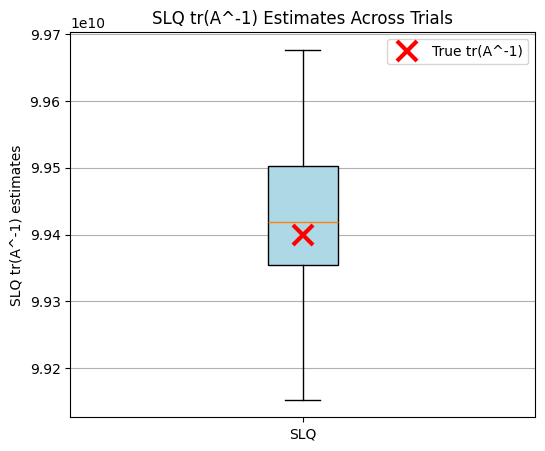

In [36]:
# Run a quick simulation to check SLQ tr(A^-1) estimator bias

num_trials = 100
slq_traces = []
for _ in range(num_trials):
    est_tr, _ = slq_trace_f(A_apply, n, s=s, m=m, f=lambda x: 1.0/x)
    slq_traces.append(est_tr)
slq_traces = np.array(slq_traces)
mean_est = np.mean(slq_traces)
std_est = np.std(slq_traces)
rel_bias = (mean_est - true_tr_Ainv) / max(1.0, abs(true_tr_Ainv))

print("\n=== SLQ tr(A^-1) Unbiasedness Simulation ===")
print(f"Trials: {num_trials}")
print(f"Mean SLQ tr(A^-1): {mean_est:.6e}")
print(f"Std  SLQ tr(A^-1): {std_est:.2e}")
print(f"True tr(A^-1):     {true_tr_Ainv:.6e}")

print(f"Relative bias:     {rel_bias:.2e}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.boxplot(slq_traces, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.plot(1, true_tr_Ainv, marker='x', color='red', markersize=14, markeredgewidth=3, linestyle='None', label='True tr(A^-1)')
plt.ylabel('SLQ tr(A^-1) estimates')
plt.title('SLQ tr(A^-1) Estimates Across Trials')
plt.xticks([1], ['SLQ'])
plt.legend()
plt.grid(axis='y')
plt.show()
